## **Amazon Sales Data Analysis: Insights into Product Ratings, Pricing, and Customer Reviews**

### **Project Objective:**
To analyze the Amazon Sales Dataset to uncover insights about product ratings, pricing, discounts, and customer reviews across different categories. The analysis will help identify trends, popular products, and factors influencing customer satisfaction.

### **Import Libraries**

In [185]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [186]:
# Load the Data from the CSV file

amazon_sales = pd.read_csv("src/amazon.csv")
amazon_sales.head(5)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


### **Data Exploration**

In [187]:
# Step 1: Data Exploration

# no of rows and columns in dataset
print('\nShape of the Dataset: ')
print(amazon_sales.shape)

# Overview of Dataset
print("\nOverview of Dataset: ")
print(amazon_sales.info())



Shape of the Dataset: 
(1465, 16)

Overview of Dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 1

- We have 1465 rows(entries) and 16 columns(attributes).
- All of our attributes are of **object** Datatype, which means that even numerical values like discounted_price, actual_price, rating count, discounted_percentage, and rating are stored as text.

### **Data Preprocessing**

In [188]:
# Step 2: Data Preprocessing

# Data Cleaning

print('\nMissing Values:')
print(amazon_sales.isna().sum())


Missing Values:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


- As we can see, we have **2** missing values in **rating_count** column out of **1465** so we are going to drop them because it makes nearly **0.14%** of total data, making it insignificant.

In [189]:
amazon_sales = amazon_sales.dropna()
print(amazon_sales.isna().sum())

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [190]:
# Check for duplicates
print("\nDuplicate Values:")
print(amazon_sales.duplicated().sum())


Duplicate Values:
0


- There are no duplicate entries in our dataset.

In [191]:
print(amazon_sales['rating'].unique())

# Remove | in 'rating' column
amazon_sales = amazon_sales[amazon_sales['rating'] != '|']

['4.2' '4.0' '3.9' '4.1' '4.3' '4.4' '4.5' '3.7' '3.3' '3.6' '3.4' '3.8'
 '3.5' '4.6' '3.2' '5.0' '4.7' '3.0' '2.8' '4' '3.1' '4.8' '2.3' '|' '2'
 '3' '2.6' '2.9']


In [192]:
# Convert columns to appropriate data types

amazon_sales['discounted_price'] = amazon_sales['discounted_price'].astype(str).str.replace('₹', '').str.replace(',', '').astype(float)
amazon_sales['actual_price'] = amazon_sales['actual_price'].astype(str).str.replace('₹', '').str.replace(',', '').astype(float)
amazon_sales['discount_percentage'] = amazon_sales['discount_percentage'].astype(str).str.replace('%', '').astype(float)
amazon_sales['rating'] = amazon_sales['rating'].astype(float)
amazon_sales['rating_count'] = amazon_sales['rating_count'].astype(str).str.replace(',','').astype(int)
amazon_sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1462 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1462 non-null   object 
 1   product_name         1462 non-null   object 
 2   category             1462 non-null   object 
 3   discounted_price     1462 non-null   float64
 4   actual_price         1462 non-null   float64
 5   discount_percentage  1462 non-null   float64
 6   rating               1462 non-null   float64
 7   rating_count         1462 non-null   int64  
 8   about_product        1462 non-null   object 
 9   user_id              1462 non-null   object 
 10  user_name            1462 non-null   object 
 11  review_id            1462 non-null   object 
 12  review_title         1462 non-null   object 
 13  review_content       1462 non-null   object 
 14  img_link             1462 non-null   object 
 15  product_link         1462 non-null   object

- We converted  **discounted_price, actual_price, discount_percentage,and rating** to float and **rating_count** to int from object so that numerical columns will not be considered as text.

In [193]:
# Basic stats
print("Summary Stats")
print(amazon_sales.describe())

Summary Stats
       discounted_price   actual_price  discount_percentage       rating  \
count       1462.000000    1462.000000          1462.000000  1462.000000   
mean        3129.981826    5453.087743            47.672367     4.096717   
std         6950.548042   10884.467444            21.613905     0.289497   
min           39.000000      39.000000             0.000000     2.000000   
25%          325.000000     800.000000            32.000000     4.000000   
50%          799.000000    1670.000000            50.000000     4.100000   
75%         1999.000000    4321.250000            63.000000     4.300000   
max        77990.000000  139900.000000            94.000000     5.000000   

        rating_count  
count    1462.000000  
mean    18307.376881  
std     42766.096572  
min         2.000000  
25%      1191.500000  
50%      5179.000000  
75%     17342.250000  
max    426973.000000  


 - Products range from **₹39 to ₹1,39,900**, with an average discount of **47.67%**, making them more affordable.
 - High average rating of **4.1/5** shows strong customer satisfaction.
 - Rating counts vary widely **(2 to 426,973)**, indicating some products are far more popular than others.
 - Discounts up to **94%** highlight aggressive pricing strategies to boost sales.

### **Exploratory Data Analysis (EDA)**

In [194]:
print('What is Plotly?')

What is Plotly?


Plotly is a Python library that creates interactive, web-based visualizations. It provides tools like Plotly Express for quick plots and Graph Objects for detailed customization.

In [195]:
import plotly.io as pio
from IPython.display import display, Image, HTML

def save_and_display(fig, filename):
    # Save PNG
    png_filename = filename.replace(".html", ".png")
    pio.write_image(fig, png_filename)
    
    # Save HTML
    html_filename = filename
    pio.write_html(fig, html_filename)
    
    # Display PNG in Notebook
    display(Image(filename=png_filename))
    
    # Provide a clickable link to the interactive plot
    display(HTML(f'<a href="{html_filename}" target="_blank">View Interactive Plot</a>'))

#### **Q1:  What is the average rating for top 10 product categories?**

In [196]:
# Avg. rating for each product category
category_avg_rating = amazon_sales.groupby('category')['rating'].mean().reset_index() 

print("\nAverage rating for top 10 product categories")

# Avg. rating for top 10 Product categories
top_categories = category_avg_rating.nlargest(10, 'rating')  # Top 10 categories

top_categories


Average rating for top 10 product categories


,category,rating
57,Computers&Accessories|Tablets,4.6
38,Computers&Accessories|Components|Memory,4.5
48,Computers&Accessories|NetworkingDevices|Networ...,4.5
62,Electronics|Cameras&Photography|Accessories|Film,4.5
81,Electronics|HomeAudio|MediaStreamingDevices|St...,4.5
118,Electronics|PowerAccessories|SurgeProtectors,4.5
123,Home&Kitchen|CraftMaterials|PaintingMaterials,4.5
148,"Home&Kitchen|Kitchen&HomeAppliances|Coffee,Tea...",4.5
175,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,4.5
194,HomeImprovement|Electrical|CordManagement,4.5


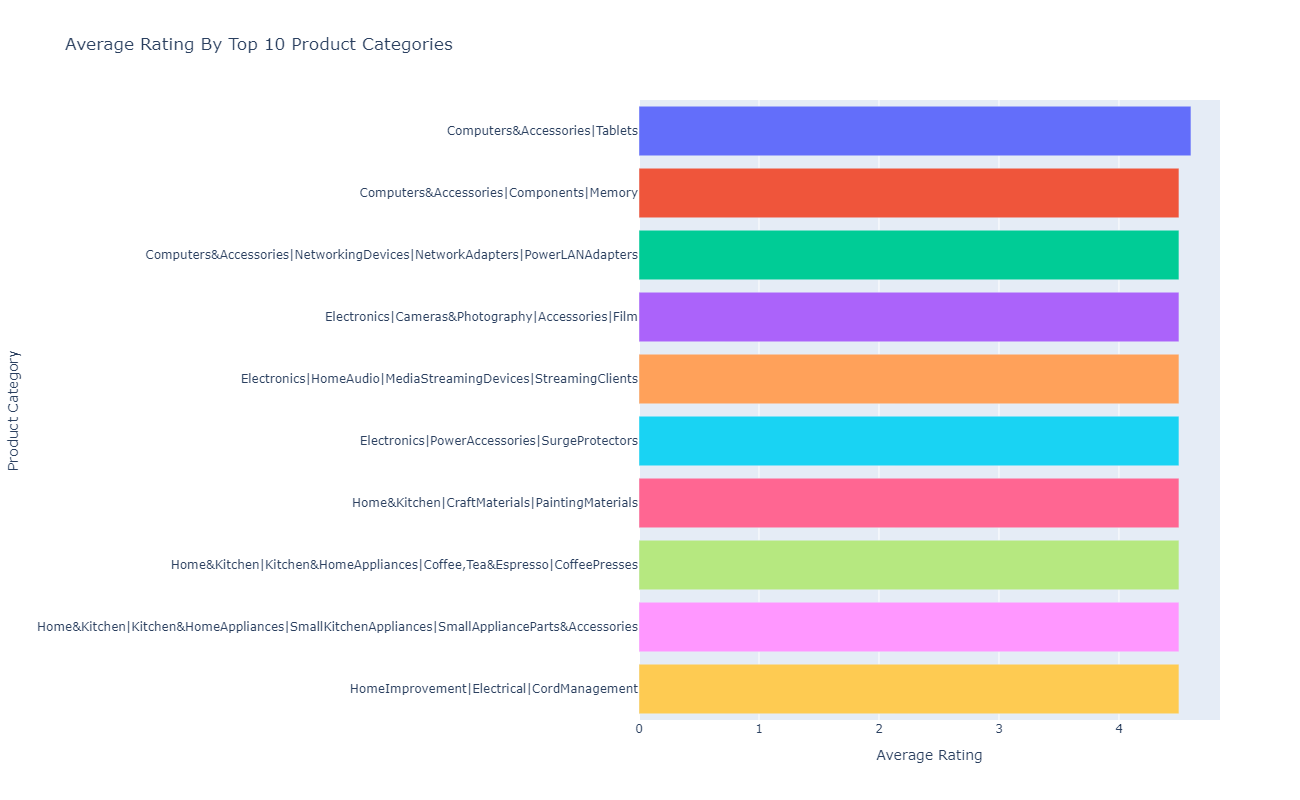

In [197]:
# bar plot for average rating for each product category
fig1 = px.bar(data_frame=top_categories, 
              x='rating', 
              y='category', 
              title='Average Rating By Top 10 Product Categories',
              orientation='h',
              color='category')  # Horizontal bar chart

fig1.update_layout(xaxis_title='Average Rating', yaxis_title='Product Category', width=1300,height=800, showlegend=False)
# fig1.show()
save_and_display(fig1, "plotlyplots/plot1.html")

- The **average rating** for the **top 10 product categories** ranges from **4.5 to 4.6**, showing high customer satisfaction across these categories.
- Tech products, home essentials, and Electronics dominating, reflecting strong customer satisfaction and market demand. 

#### **Q2: What are the top rated products by category?**

In [198]:
print("\nTop rated products by category")

top_products_by_category = amazon_sales.groupby(['category', 'product_name'])['rating_count'].max().reset_index()
top_products_by_category = top_products_by_category.sort_values(by='rating_count', ascending=False).head(10)
top_products_by_category


Top rated products by category


,category,product_name,rating_count
500,"Electronics|HomeTheater,TV&Video|Accessories|C...","Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",426973
505,"Electronics|HomeTheater,TV&Video|Accessories|C...",AmazonBasics Flexible Premium HDMI Cable (Blac...,426973
499,"Electronics|HomeTheater,TV&Video|Accessories|C...","Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",426973
459,"Electronics|Headphones,Earbuds&Accessories|Hea...",boAt Bassheads 100 in Ear Wired Earphones with...,363713
458,"Electronics|Headphones,Earbuds&Accessories|Hea...",boAt Bassheads 100 in Ear Wired Earphones with...,363713
456,"Electronics|Headphones,Earbuds&Accessories|Hea...",boAt BassHeads 100 in-Ear Wired Headphones wit...,363711
749,Electronics|Mobiles&Accessories|Smartphones&Ba...,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",313836
747,Electronics|Mobiles&Accessories|Smartphones&Ba...,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",313836
748,Electronics|Mobiles&Accessories|Smartphones&Ba...,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...",313832
750,Electronics|Mobiles&Accessories|Smartphones&Ba...,"Redmi 9A Sport (Coral Green, 3GB RAM, 32GB Sto...",313832


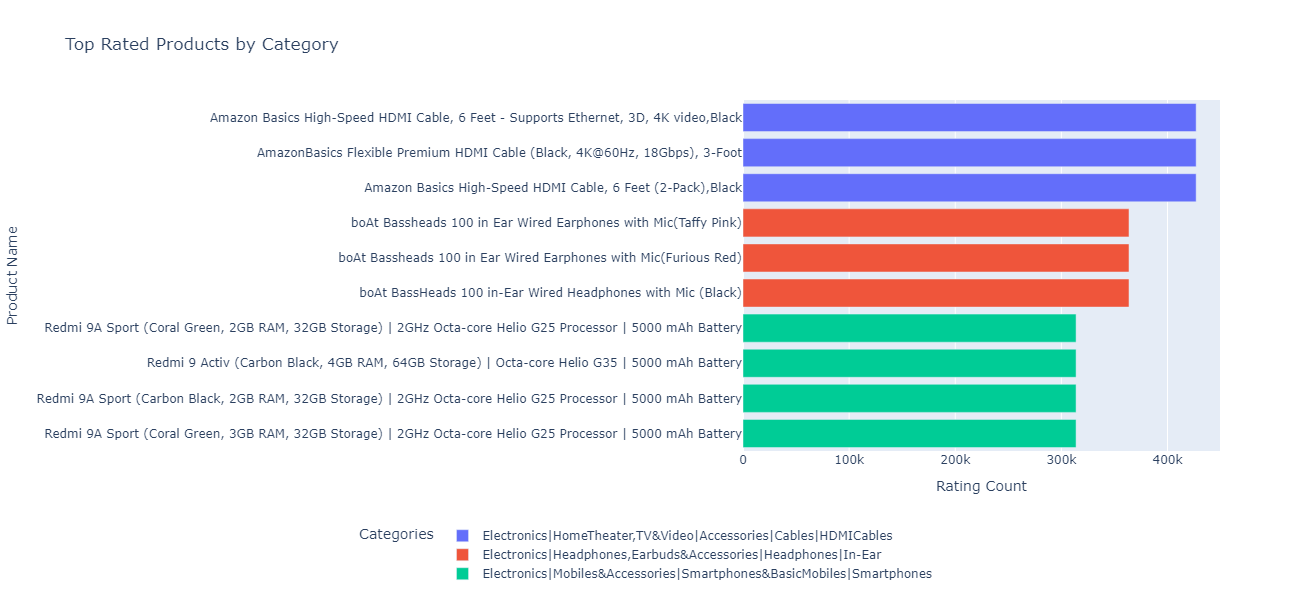

In [199]:
# bar plot for top rated product by category

fig2 = px.bar(data_frame=top_products_by_category,
              x='rating_count',
              y='product_name',
              color='category',
              title='Top Rated Products by Category',
              orientation='h',
              category_orders={"product_name": top_products_by_category["product_name"].tolist()}
              )

fig2.update_layout(yaxis_title='Product Name', xaxis_title='Rating Count',width=1300,height= 600, showlegend=True, legend=dict(
        title="Categories",
        orientation="h",  # Horizontal legend
        yanchor="top",  # Align to top
        y=-0.2,  # Move legend below the plot
        xanchor="center",  # Center align
        x=-0.2 
    )
)
# fig2.show()
save_and_display(fig2, "plotlyplots/plot2.html")

- **Amazon Basics HDMI cables(426.973k)**, **boAt Bassheads earphones(363.713k)**, and **Redmi 9A Sport/9 Activ smartphones(313.836k)** are the top-rated products in their respective categories.
- High Rating count suggests strong demand for these products.

#### **Q3: What is the distribution of discounted prices vs. actual prices?**


Distribution of discounted prices vs. actual prices


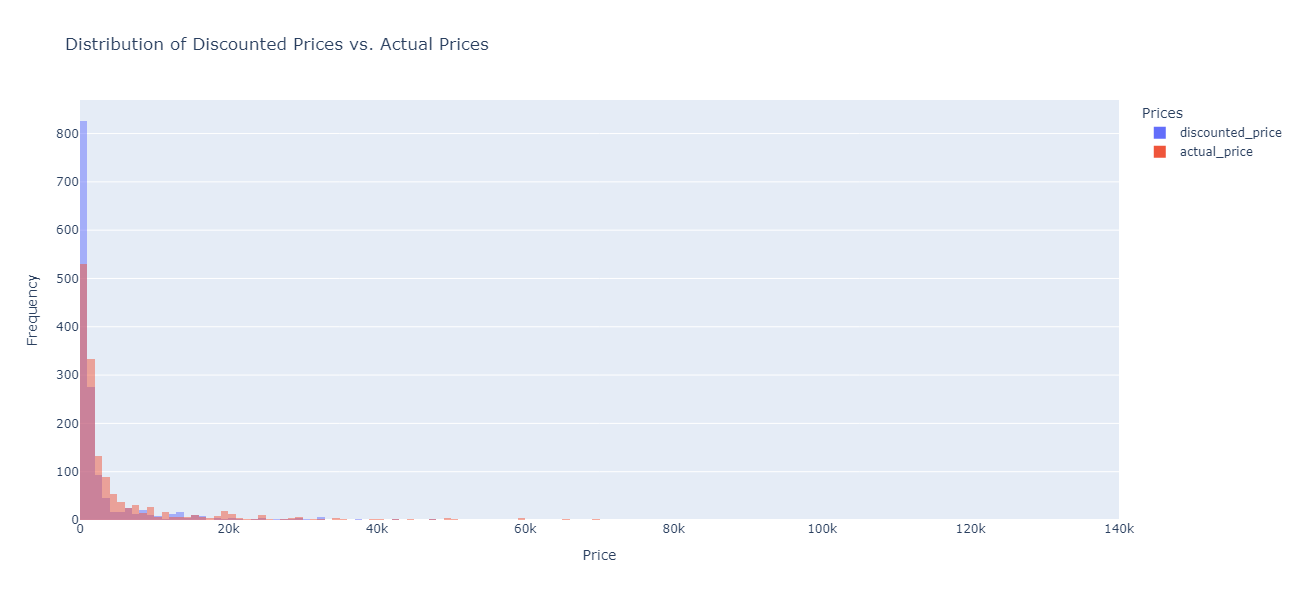

In [200]:
print('\nDistribution of discounted prices vs. actual prices')

fig3 = px.histogram(amazon_sales, x=['discounted_price', 'actual_price'], barmode='overlay', 
                    title='Distribution of Discounted Prices vs. Actual Prices')
fig3.update_layout(xaxis_title='Price', yaxis_title='Frequency',width=1300,height=600, legend=dict(title="Prices"))
# fig3.show()
save_and_display(fig3, "plotlyplots/plot3.html")


- The histogram shows that most products have **lower prices**, with both **actual** and **discounted** prices skewed towards the **lower end**. 
- Discounted prices (blue) are generally **lower** than actual prices (red), indicating that products are generally being sold at a discount.
- Few high-priced products exist, but they are rare. 
- The overlap suggests some items have minimal or no discounts.

#### **Q4: How does the average discount percentage vary across the top 10 discounted categories??**

In [201]:
print('\nAverage discount Percentage across top 10 discounted categories')
category_avg_discount = amazon_sales.groupby('category')['discount_percentage'].mean().reset_index()
top_discounted_categories = category_avg_discount.nlargest(10, 'discount_percentage').sort_values(by='discount_percentage', ascending=False)
top_discounted_categories


Average discount Percentage across top 10 discounted categories


,category,discount_percentage
6,Computers&Accessories|Accessories&Peripherals|...,90.0
75,"Electronics|Headphones,Earbuds&Accessories|Ear...",90.0
106,Electronics|Mobiles&Accessories|MobileAccessor...,90.0
73,"Electronics|Headphones,Earbuds&Accessories|Ada...",88.0
14,Computers&Accessories|Accessories&Peripherals|...,87.5
110,Electronics|Mobiles&Accessories|MobileAccessor...,82.0
36,Computers&Accessories|Components|InternalHardD...,80.0
1,Computers&Accessories|Accessories&Peripherals|...,78.5
114,Electronics|Mobiles&Accessories|MobileAccessor...,76.4
74,"Electronics|Headphones,Earbuds&Accessories|Cases",76.0


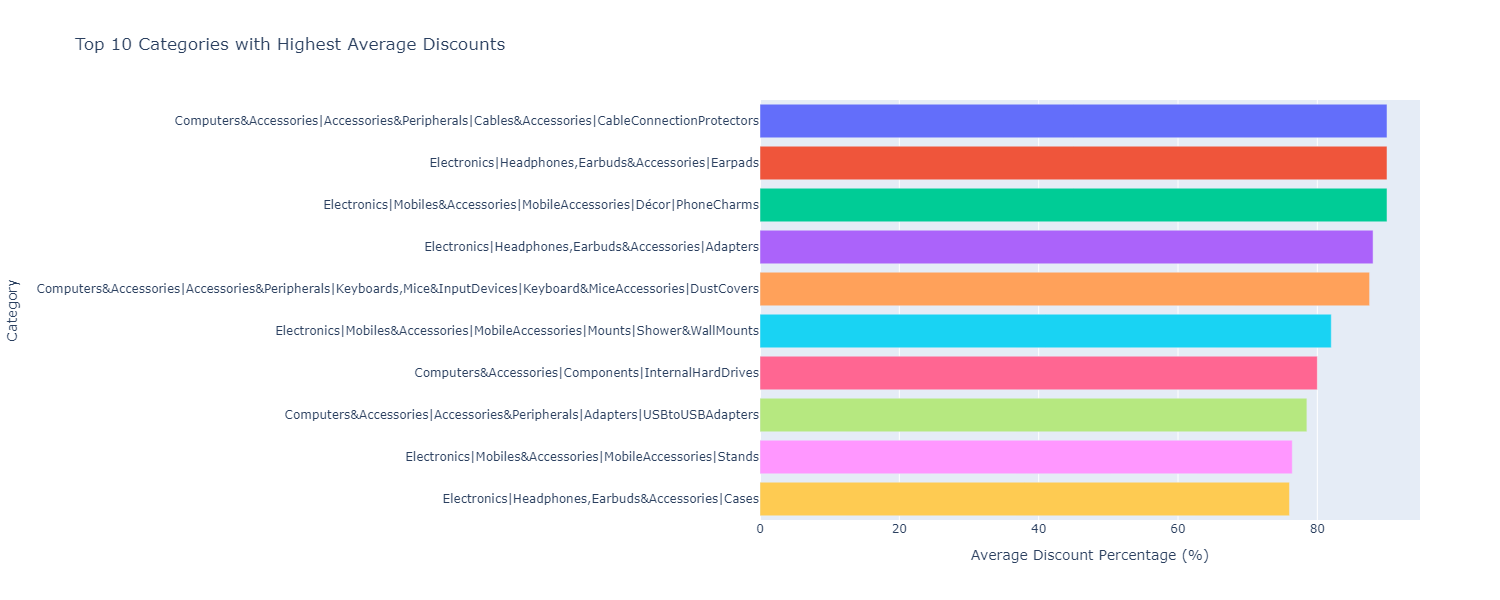

In [202]:
# bar chart for how average discount percentage varies across top 10 discounted categories
fig4 = px.bar(top_discounted_categories, x='discount_percentage', y='category', 
              title='Top 10 Categories with Highest Average Discounts', orientation='h', color='category')
fig4.update_layout(xaxis_title='Average Discount Percentage (%)', yaxis_title='Category',width=1500,height=600, showlegend=False)
# fig4.show()
save_and_display(fig4, "plotlyplots/plot4.html")

- **Top 3 discounted categories (90%):** Cable Connection Protectors, Earpads, Phone Charms.
- **Electronics & Accessories** dominate, with all top 10 categories having **75%+ discounts**.
- Likely clearance sales or bundling strategy to boost purchases.

#### **Q5: What are the most popular product names?**

In [203]:
print("\nMost popular product names")
product_name_counts = amazon_sales['product_name'].value_counts().head(10).reset_index()
product_name_counts


Most popular product names


,product_name,count
0,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",5
1,Fire-Boltt Phoenix Smart Watch with Bluetooth ...,4
2,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,3
3,pTron Solero TB301 3A Type-C Data and Fast Cha...,3
4,Duracell USB C To Lightning Apple Certified (M...,3
5,boAt A400 USB Type-C to USB-A 2.0 Male Data Ca...,3
6,Flix Micro Usb Cable For Smartphone (Black),3
7,Amazonbasics Nylon Braided Usb-C To Lightning ...,3
8,Sounce Fast Phone Charging Cable & Data Sync U...,3
9,Wayona Nylon Braided USB to Lightning Fast Cha...,3


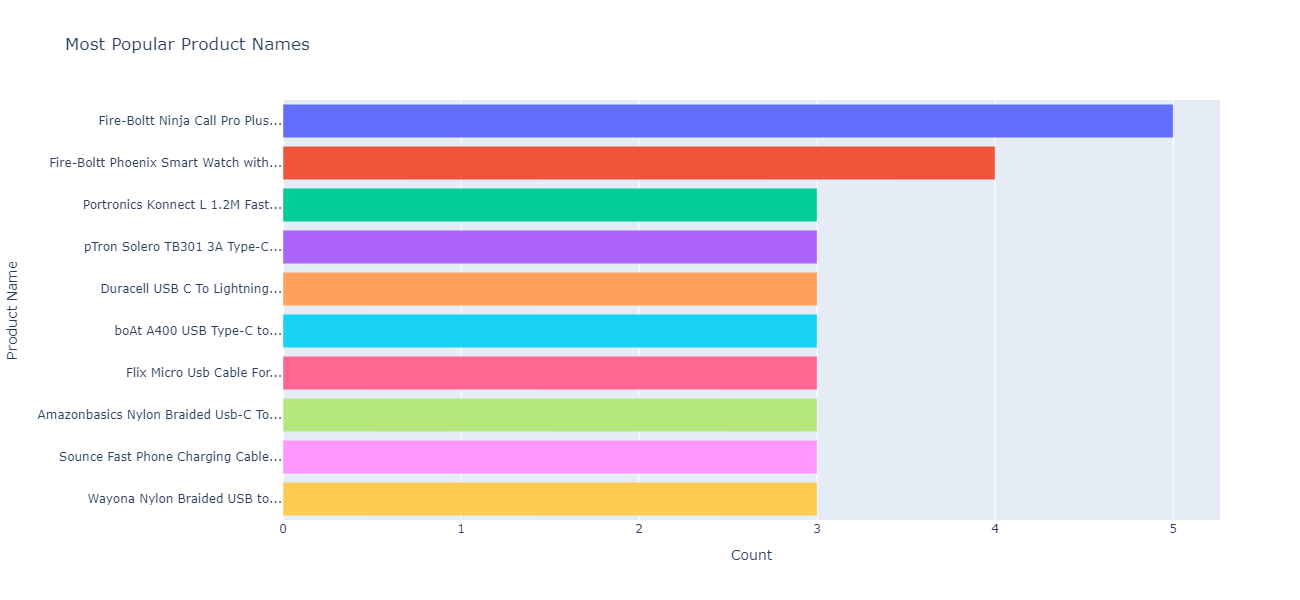

In [204]:
# Bar chart for the most popular product names
product_name_counts['short_name'] = product_name_counts['product_name'].apply(lambda x: ' '.join(x.split()[:5]) + '...')
fig5 = px.bar(product_name_counts, x='count', y='short_name', 
              title='Most Popular Product Names', orientation='h',color='short_name')
fig5.update_layout(xaxis_title='Count', yaxis_title='Product Name', showlegend=False, width=1300, height=600)
# fig5.show()
save_and_display(fig5, "plotlyplots/plot5.html")

- **Smartwatches dominate the top spots**, with Fire-Boltt leading the sales.  
- **Charging cables make up 80% of the top 10 products**, indicating high consumer demand.  
- **Brands like Fire-Boltt, boAt, Portronics, and pTron are popular for accessories.**  
- **Consumers prefer durable, fast-charging, and nylon-braided cables.**  

#### **Q6: What are the most popular product keywords?**

In [205]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [206]:
print("\nMost popular product keywords")
stop_words = set(stopwords.words('english'))

# Clean text: Remove punctuation, convert to lowercase, and split into words
keywords = amazon_sales['about_product'].str.lower().str.replace(r'[^\w\s]', '', regex=True).str.split().explode()

# Remove stopwords, single-character words, and numeric values
keywords = keywords[~keywords.isin(stop_words)]
keywords = keywords[keywords.str.len() > 1]  # Remove single-character words
keywords = keywords[~keywords.str.isnumeric()]  # Remove numbers

keyword_counts = keywords.value_counts().head(10).reset_index()
keyword_counts.columns = ['keyword', 'count']
keyword_counts


Most popular product keywords


,keyword,count
0,usb,1003
1,cable,821
2,charging,617
3,warranty,497
4,power,493
5,design,471
6,devices,467
7,use,457
8,easy,430
9,type,408


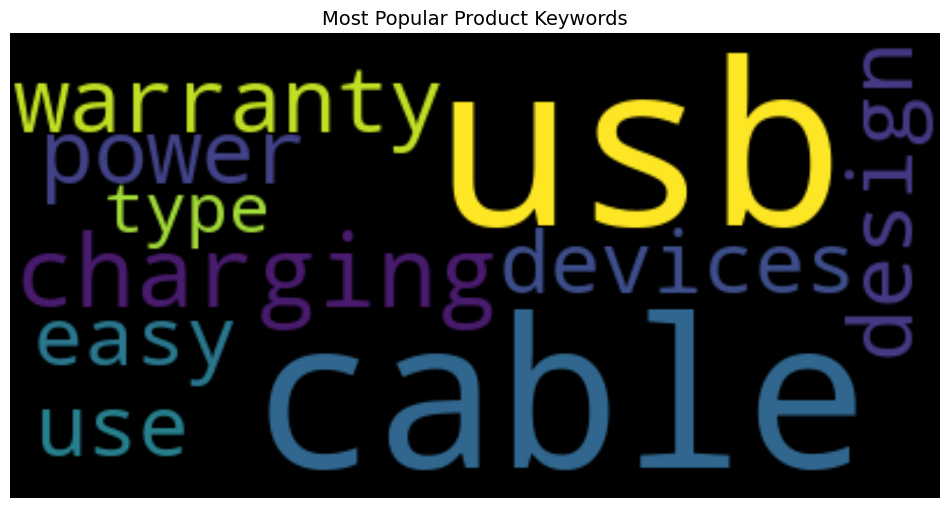

In [207]:
import matplotlib.pyplot as plt

# Generate word cloud
wordcloud = WordCloud(background_color='black').generate_from_frequencies(dict(zip(keyword_counts['keyword'], keyword_counts['count'])))

# Display the word cloud
plt.figure(figsize=(12,20))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  # Hide axis
plt.title("Most Popular Product Keywords", fontsize=14)
plt.show()

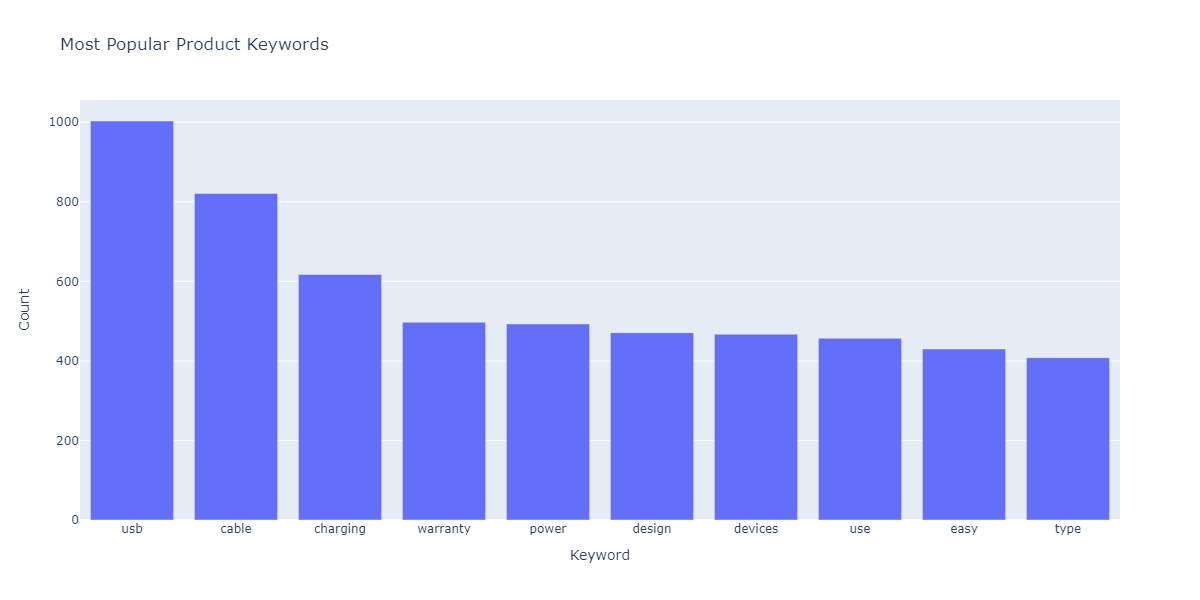

In [208]:
fig6 = px.bar(keyword_counts, x='keyword', y='count', 
              title='Most Popular Product Keywords')
fig6.update_layout(xaxis_title='Keyword', yaxis_title='Count',height=600, width=1200)
# fig6.show()
save_and_display(fig6, "plotlyplots/plot6.html")

- **USB** is the most frequently mentioned keyword, indicating high demand for USB-related products.  
- Other common keywords like **cable, charging, and power** highlight a focus on charging accessories.  
- **Warranty** appears frequently, showing that customers value product guarantees.  
- Keywords like **design and easy** suggest product aesthetics and ease of use matter to buyers.  
- The **word cloud** visually highlights the most common keywords, with larger words indicating higher frequency.  
- The **bar chart** provides a clear numerical comparison of keyword popularity

#### **Q7: What are the most popular product reviews?**

In [209]:
from textblob import TextBlob

print("\nMost popular product reviews")

# giving polarity score to each review
amazon_sales['review_sentiment'] = amazon_sales['review_content'].apply(lambda x: TextBlob(x).sentiment.polarity) 

# categorizing sentiments into : positive, negative and neutral.
amazon_sales['sentiment_category'] = amazon_sales['review_sentiment'].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'neutral')) 

# counting sentiment categories
sentiment_distribution = amazon_sales['sentiment_category'].value_counts().reset_index()
sentiment_distribution.columns = ['sentiment', 'count']
sentiment_distribution


Most popular product reviews


,sentiment,count
0,positive,1435
1,negative,26
2,neutral,1


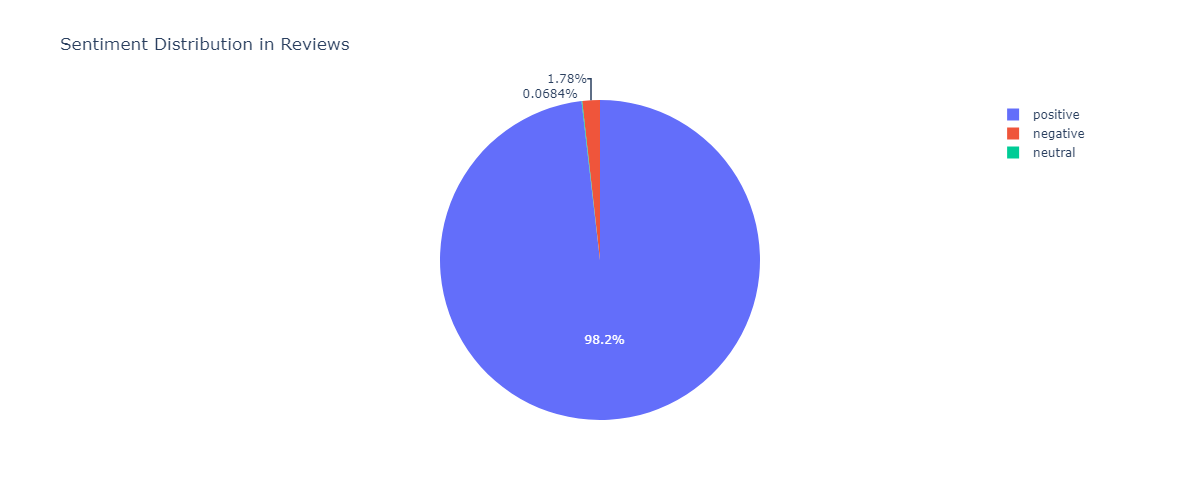

In [210]:
# pie chart to display sentiment proportions
fig7 = px.pie(sentiment_distribution, values='count', names='sentiment', 
              title='Sentiment Distribution in Reviews')
fig7.update_layout(width=1200,height=500)
# fig7.show()
save_and_display(fig7, "plotlyplots/plot7.html")

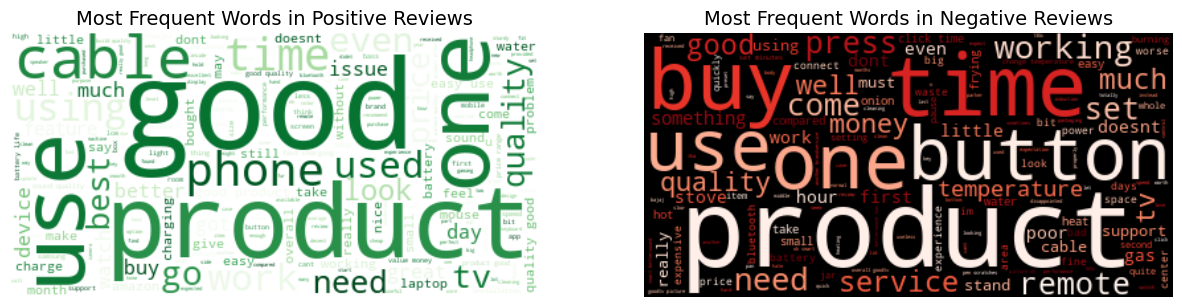

In [211]:
# Word cloud for the most frequent words in positive and negative reviews.

# Filter positive and negative reviews
positive_reviews = amazon_sales[amazon_sales['sentiment_category'] == 'positive']['review_content']
negative_reviews = amazon_sales[amazon_sales['sentiment_category'] == 'negative']['review_content']

# Function to clean and extract words
def get_cleaned_text(reviews):
    words = reviews.str.lower().str.replace(r'[^\w\s]', '', regex=True).str.split().explode()
    words = words[~words.isin(stop_words)]  # Remove stopwords
    return words

# Get most frequent words in positive and negative reviews
positive_words = get_cleaned_text(positive_reviews)
negative_words = get_cleaned_text(negative_reviews)

# Generate Word Clouds
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Positive reviews word cloud
wordcloud_positive = WordCloud(background_color='white', colormap='Greens').generate(' '.join(positive_words))
axes[0].imshow(wordcloud_positive, interpolation='bilinear')
axes[0].axis("off")
axes[0].set_title("Most Frequent Words in Positive Reviews", fontsize=14)

# Negative reviews word cloud
wordcloud_negative = WordCloud(background_color='black', colormap='Reds').generate(' '.join(negative_words))
axes[1].imshow(wordcloud_negative, interpolation='bilinear')
axes[1].axis("off")
axes[1].set_title("Most Frequent Words in Negative Reviews", fontsize=14)

plt.show()

**Sentiment Distribution**:  
  - **98.2%** of reviews are **positive**.  
  - **1.78%** are **negative**.  
  - **0.068%** are **neutral**.  

**Most Frequent Words in Reviews**:  
  - **Positive Reviews**: "product," "use," "one," "phone," "cable," "good," "time."  
  - **Negative Reviews**: "product," "buy," "button," "time," "working," "need," "remote."  

We can say that:
- Most customers are **highly satisfied**.  
- **Common issues** may include product usability, buttons, and remote functionality.

#### **Q8: What is the correlation between discounted_price and rating?**

In [212]:
print("\nCorrelation between discounted_price and rating")
correlation = amazon_sales['discounted_price'].corr(amazon_sales['rating'])
print("\nCorrelation coefficient:", correlation)


Correlation between discounted_price and rating

Correlation coefficient: 0.12113187526066276


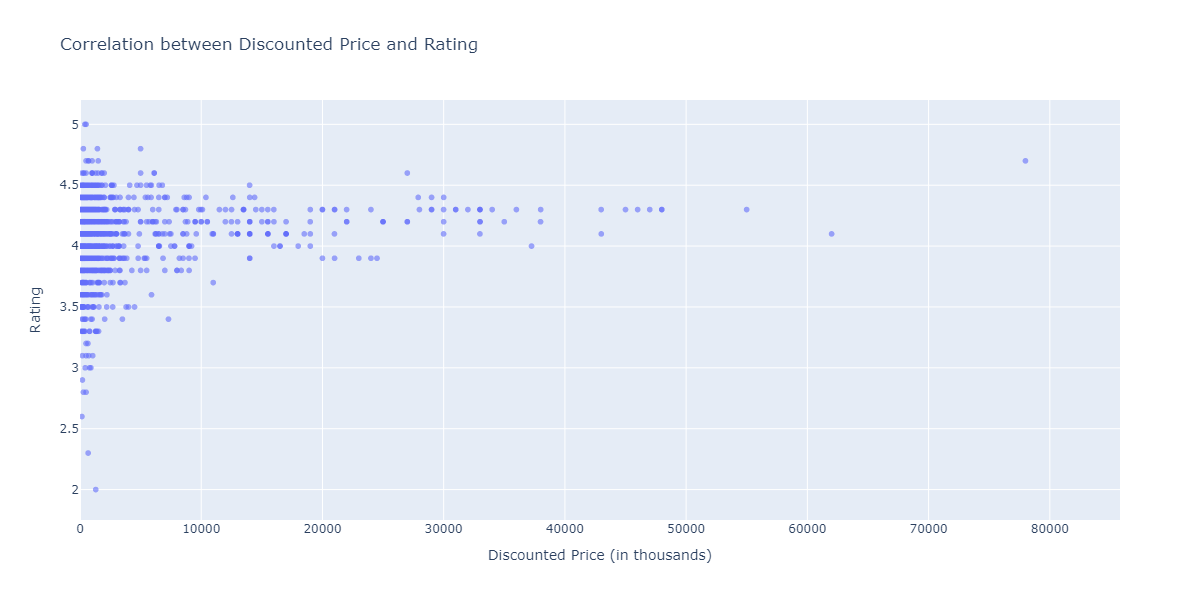

In [213]:
fig8 = px.scatter(amazon_sales, x='discounted_price', y='rating',
                  title='Correlation between Discounted Price and Rating',
                  opacity=0.6, labels={'discounted_price': 'Discounted Price (in thousands)', 'rating': 'Rating'})

fig8.update_layout(
    xaxis_title='Discounted Price (in thousands)',
    yaxis_title='Rating',
    xaxis=dict(tickformat=".0f", range=[0, amazon_sales['discounted_price'].max() * 1.1]),  # Adjust x-axis range
    yaxis=dict(tickvals=[2, 2.5, 3, 3.5, 4, 4.5, 5], range=[1.75, 5.2]),  # Set specific y-axis ticks and range
    showlegend=False,
    height=600,
    width=1200
)

# fig8.show()
save_and_display(fig8, "plotlyplots/plot8.html")

- **Correlation Coefficient**: `0.1211` → Indicates a **very weak positive correlation** between **discounted price** and **rating**, meaning higher prices do not significantly impact ratings.
- Ratings are **mostly between 3.5 and 5**, regardless of price, with **few high-priced products** maintaining good ratings.
- We can say that, Price has a **minimal effect** on customer ratings, suggesting that other factors (e.g., quality, brand, features) influence ratings more than price.


### **Conclusion: Key Insights from Amazon Sales Data Analysis**

After analyzing Amazon sales data, we can summarize the key findings based on our objectives:

#### **1. Product Ratings & Customer Reviews**
- The **average product rating** is high, with most ratings falling between **3.5 and 5 stars**.
- Sentiment analysis shows that **98.2% of reviews are positive**, indicating high customer satisfaction.
- Common positive review words: *"product," "use," "good," "phone," "cable."*
- Negative reviews highlight issues like *"buttons not working," "remote issues," and "poor durability."*

#### **2. Pricing & Discounts Impact on Ratings**
- The correlation between **discounted price and rating is weak (0.1211)**, meaning price reductions **do not significantly influence customer ratings**.
- Customers seem to focus more on **quality and brand reputation** than just price.

#### **3. Keyword & Feature Analysis**
- Frequently mentioned keywords: **USB, cable, charging, power, warranty, design, easy.**
- These keywords suggest that **customers prioritize ease of use, warranty coverage, and product reliability**.

#### **4. Trends in Product Demand**
- **Charging accessories (USB cables, power banks) are among the most frequently purchased products.**
- The **word cloud visualization** further highlights customer preferences and trending product categories.

#### **Final Takeaway**
The analysis indicates that **quality, ease of use, and brand reputation** drive customer satisfaction more than just pricing. Retailers should **focus on product durability, warranty offerings, and feature-rich products** to attract customers.The use of **Plotly** for visualizations has allowed for an interactive and detailed exploration of the data, highlighting significant trends and patterns. This project has successfully demonstrated the application of data analysis techniques to uncover actionable insights, contributing to a better understanding of factors influencing customer satisfaction and sales performance.